# Continuous-Time TD3-BC: Comparison Experiment

Compares **论文原版 TD3-BC (baseline)** against **Approach A: TD3-BC-ct** under identical conditions.

- Patient: `adult#1` (paper default)
- Seeds: `0, 1, 2`
- Buffer: shared PID demonstrator replay (collected once, reused by both algorithms)
- A-method continuous-time hyperparams: `dt = 3.0 min`, `beta = -ln(0.99)/3`, so `exp(-beta*dt) = 0.99`
  → mathematically equivalent to paper's `gamma = 0.99` up to a `dt` factor on the reward, which the BC term's adaptive λ absorbs.

Pass criterion for A: TIR / TBR not significantly worse than baseline across 3 seeds → proceed to Approach C (HJB regularisation).

In [1]:
# INITIALISE THE ENVIRONMENT ----------------------
import torch, warnings
print("CUDA available:", torch.cuda.is_available())
# Quick GPU compatibility probe: try a tiny CUDA op; if PyTorch warns the
# device arch is unsupported (e.g. RTX 50-series with old PyTorch), fall back
# to CPU. This avoids silently running at CPU speed via partial fallback,
# which can corrupt loss scales and gradient stability.
# We catch the broadest possible Exception here on purpose -- PyTorch can
# raise UserWarning, RuntimeError, or DeferredCudaCallError depending on
# how the incompatibility surfaces.
GPU_USABLE = False
if torch.cuda.is_available():
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("error", UserWarning)
            _t = torch.zeros(1, device="cuda") + 1.0
        GPU_USABLE = True
        print("GPU usable:", torch.cuda.get_device_name(0))
    except Exception as e:
        print("GPU NOT usable, falling back to CPU. Reason:")
        print(" ", type(e).__name__ + ":", str(e).splitlines()[0])

import numpy as np
from utils import create_env

# Set the parameters for the meal scenario (same as paper)
prob = [0.95, 0.1, 0.95, 0.1, 0.95, 0.1]
time_lb = np.array([5, 9, 10, 14, 16, 20])
time_ub = np.array([9, 10, 14, 16, 20, 23])
time_mu = np.array([7, 9.5, 12, 15, 18, 21.5])
time_sigma = np.array([30, 15, 30, 15, 30, 15])
amount_mu = [50, 15, 70, 15, 90, 30]
amount_sigma = [10, 5, 10, 5, 10, 5]
schedule = [prob, time_lb, time_ub, time_mu, time_sigma, amount_mu, amount_sigma]

# Idempotent: gym raises if an id is re-registered, so swallow that one error.
# This makes the cell safe to re-run without restarting the kernel.
try:
    create_env(schedule=schedule)
    print("Environments registered.")
except Exception as e:
    if "re-register" in str(e):
        print("Environments already registered (skipping).")
    else:
        raise

c:\ProgramData\miniconda3\envs\offline-glucose\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: True
GPU NOT usable, falling back to CPU. Reason:
  DeferredCudaCallError: CUDA call failed lazily at initialization with error: 
Environments registered.


In [ ]:
# SPECIFY THE PARAMETERS -----------------------

import math
from utils import get_params

patient_params = get_params()["adult#1"]
bas = patient_params["u2ss"] * (patient_params["BW"] / 6000) * 3

# Continuous-time hyperparameters for Approach A.
# At dt=3.0 and beta=-ln(0.99)/3, exp(-beta*dt)=0.99 = paper's gamma.
DT = 3.0
BETA = -math.log(0.99) / 3.0

# Auto-pick device based on the probe in cell 1. If GPU_USABLE is False the
# probe found that PyTorch does not actually support this GPU (e.g. RTX
# 50-series + PyTorch 1.7), so we MUST use CPU -- otherwise training would
# silently fall back partway and corrupt loss scales.
DEVICE = "cuda" if globals().get("GPU_USABLE", False) else "cpu"
print(f"Training device: {DEVICE}")

# ----- Quick-iteration mode -----
# We're verifying that A matches baseline qualitatively, NOT publishing
# numbers. Use shorter training and a single seed to get feedback in
# minutes, not hours. Bump these up before reporting final results.
QUICK = False
TRAINING_STEPS = int(5e4) if QUICK else int(1e5)   # 50k for quick check
SEEDS          = [0]       if QUICK else [0, 1, 2]

params = {
    # Environmental
    "state_size": 3,
    "basal_default": bas,
    "target_blood_glucose": 144.0,
    "days": 10,

    # PID and Bolus
    "carbohydrate_ratio": patient_params["carbohydrate_ratio"],
    "correction_factor":  patient_params["correction_factor"],
    "kp": patient_params["kp"],
    "ki": patient_params["ki"],
    "kd": patient_params["kd"],

    # RL
    "training_timesteps": TRAINING_STEPS,
    "device": DEVICE,
    "rnn": None,

    # Continuous-time (only used by td3_bc_ct; ignored by paper baseline)
    "dt": DT,
    "beta": BETA,
}

print(f"Patient: adult#1   bas={bas:.4f}")
print(f"Mode:    {'QUICK' if QUICK else 'FULL'}  (steps={TRAINING_STEPS:,}, seeds={SEEDS})")
print(f"CT params: dt={DT} min, beta={BETA:.6e} /min, exp(-beta*dt)={math.exp(-BETA*DT):.6f}")

Training device: cpu
Patient: adult#1   bas=0.0634
Mode:    QUICK  (steps=50,000, seeds=[0])
CT params: dt=3.0 min, beta=3.350112e-03 /min, exp(-beta*dt)=0.990000


## 1. Collect the shared replay buffer

PID demonstrator data, **identical buffer** used by both baseline and Approach A.

In [3]:
# COLLECT THE DATA --------------------------------

import os, gym
from utils import fill_replay_split

replay_path = f"./Replays/{patient_params['replay_name']}.txt"

if os.path.exists(replay_path):
    print(f"Replay already exists: {replay_path}  (skipping collection)")
else:
    env = gym.make(patient_params["env_name"])
    full_replay = fill_replay_split(
        env=env,
        replay_name=patient_params["replay_name"],
        data_split=0.0,
        noise=True,
        bolus_noise=0.1,
        seed=0,
        params=params,
    )
    print(f"Replay saved to: {replay_path}")

Replay already exists: ./Replays/Adult#1-1e5.txt  (skipping collection)


## 2. Train both algorithms across seeds

Each cell trains all 3 seeds for one algorithm. **Heavy compute step** — expect this to be the bulk of runtime.

In [4]:
# TRAIN BASELINE: 论文原版 TD3-BC --------------------
# Memory-conscious version: trains one seed at a time, releases memory
# after each seed (deletes agent, runs gc).
# Uses the global SEEDS list (set by cell 2). Skips seeds whose weights
# already exist on disk -- so you can resume after a crash.

import gc, os
from TD3_BC import td3_bc

for seed in SEEDS:
    suffix = patient_params["replay_name"].split("-")[-1]
    weight_path = f"./Models/{patient_params['env_name']}{seed}TD3_offline_BC_weights_actor{suffix}"
    if os.path.exists(weight_path):
        print(f"========== Baseline seed={seed}: weights exist, SKIPPING ==========")
        continue

    print(f"\n========== Baseline TD3-BC, seed={seed} ==========")
    agent = td3_bc(init_seed=seed, patient_params=patient_params, params=dict(params))
    agent.train_model()
    del agent
    gc.collect()

print("\nBaseline training done.")

========== Baseline seed=0: weights exist, SKIPPING ==========

Baseline training done.


In [5]:
# TRAIN APPROACH A: TD3-BC-ct ------------------------
# Same memory-conscious pattern as the baseline cell above.

import gc, os
from TD3_BC_ct import td3_bc_ct

for seed in SEEDS:
    suffix = patient_params["replay_name"].split("-")[-1]
    weight_path = f"./Models/{patient_params['env_name']}{seed}TD3_offline_BC_ct_weights_actor{suffix}"
    if os.path.exists(weight_path):
        print(f"========== TD3-BC-ct seed={seed}: weights exist, SKIPPING ==========")
        continue

    print(f"\n========== TD3-BC-ct (Approach A), seed={seed} ==========")
    agent = td3_bc_ct(init_seed=seed, patient_params=patient_params, params=dict(params))
    agent.train_model()
    del agent
    gc.collect()

print("\nApproach A training done.")

========== TD3-BC-ct seed=0: weights exist, SKIPPING ==========

Approach A training done.


In [6]:
# TRAIN APPROACH C: TD3-BC-ct + HJB regularisation ----------
# v3: drift estimated by a small neural network (DriftNet) trained
# alongside the critic. The HJB term is suppressed for the first
# `drift_warmup_steps` so DriftNet can learn the FD signal first.
#
# Earlier versions for reference:
#   v1: drift_mode="fd", phys_idx=all 11 dims     -> ΔTIR -11.6
#   v2: drift_mode="fd", phys_idx=[8,9,10]        -> ΔTIR  -5.1
#   v3: drift_mode="net", phys_idx=[8,9,10]       -> ?

import gc, os
from TD3_BC_ct import td3_bc_ct

LAMBDA_HJB         = 1.0     # HJB residual weight in the critic loss
DRIFT_MODE         = "net"   # "net" = DriftNet; "fd" = raw finite difference
DRIFT_WARMUP_STEPS = 5000    # critic steps with HJB suppressed

for seed in SEEDS:
    suffix = patient_params["replay_name"].split("-")[-1]
    weight_path = f"./Models/{patient_params['env_name']}{seed}TD3_offline_BC_ct_hjb_net_weights_actor{suffix}"
    if os.path.exists(weight_path):
        print(f"========== Approach C (HJB+net) seed={seed}: weights exist, SKIPPING ==========")
        continue

    print(f"\n========== Approach C: TD3-BC-ct + HJB+net, seed={seed}, lambda={LAMBDA_HJB} ==========")
    hjb_params = dict(params)
    hjb_params["use_hjb"] = True
    hjb_params["lambda_hjb"] = LAMBDA_HJB
    hjb_params["drift_mode"] = DRIFT_MODE
    hjb_params["drift_warmup_steps"] = DRIFT_WARMUP_STEPS
    agent = td3_bc_ct(init_seed=seed, patient_params=patient_params, params=hjb_params)
    agent.train_model()
    del agent
    gc.collect()

print("\nApproach C training done.")


========== Approach C: TD3-BC-ct + HJB+net, seed=0, lambda=1.0 ==========


c:\ProgramData\miniconda3\envs\offline-glucose\lib\site-packages\gym\envs\registration.py:17: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


Processing Complete.
Timesteps 5000 - Actor Loss 2.584129810333252 - Critic Loss 21.127429962158203 - HJB Loss 0.0 - Drift Loss 0.00026359831099398434
Timesteps 10000 - Actor Loss 2.563471794128418 - Critic Loss 71.179443359375 - HJB Loss 27.97698211669922 - Drift Loss 0.004983299411833286
Timesteps 15000 - Actor Loss 2.547045946121216 - Critic Loss 129.02655029296875 - HJB Loss 36.015174865722656 - Drift Loss 0.00429779477417469
Timesteps 20000 - Actor Loss 2.526060104370117 - Critic Loss 116.56795501708984 - HJB Loss 26.730628967285156 - Drift Loss 0.005993449594825506
Timesteps 25000 - Actor Loss 2.5213701725006104 - Critic Loss 110.17013549804688 - HJB Loss 29.47047233581543 - Drift Loss 0.0011195013066753745
Timesteps 30000 - Actor Loss 2.5189526081085205 - Critic Loss 301.6067810058594 - HJB Loss 24.005340576171875 - Drift Loss 0.0031055633444339037
Timesteps 35000 - Actor Loss 2.5147206783294678 - Critic Loss 416.63031005859375 - HJB Loss 26.682388305664062 - Drift Loss 0.001705

## 3. Evaluation utilities

Compute clinical metrics from a blood-glucose trace.

- **TIR** (Time in Range): % time in [70, 180] mg/dL  — *higher is better*
- **TBR** (Time Below Range): % time < 70 mg/dL  — *lower is better, the safety metric*
- **TAR** (Time Above Range): % time > 180 mg/dL  — *lower is better*
- **Severe hypo**: % time < 54 mg/dL
- **Magni risk**: paper's reward proxy, lower = safer
- **Failure**: any step BG < 40 (terminates episode in env, paper uses ‑1e5 reward)

In [7]:
import numpy as np
from utils.general import calculate_risk

def clinical_metrics(bg_trace):
    """Compute TIR/TBR/TAR/Magni/failure from a 1-D BG trace (mg/dL)."""
    bg = np.asarray(bg_trace, dtype=float)
    if bg.size == 0:
        return {k: float('nan') for k in ["TIR","TBR","TAR","sev_hypo","magni","mean_bg","failure"]}
    n = bg.size
    return {
        "TIR":      100.0 * np.mean((bg >= 70) & (bg <= 180)),
        "TBR":      100.0 * np.mean(bg < 70),
        "TAR":      100.0 * np.mean(bg > 180),
        "sev_hypo": 100.0 * np.mean(bg < 54),
        "magni":    float(np.mean([calculate_risk([float(x)]) for x in bg])),
        "mean_bg":  float(np.mean(bg)),
        "failure":  int(np.any(bg < 40)),
    }

## 4. Run test rollouts and collect BG traces

Avoid the paper's `agent.test_model()` (which calls `create_graph`, plotting and stat-printing for one seed). We call `test_algorithm` directly so we can control the seeds and collect raw BG traces.

In [8]:
import gym, copy, os
from utils import unpackage_replay
from utils.evaluation import test_algorithm
from collections import deque
import pickle

TEST_SEED = 0          # rollout seed (paper convention: differs from training seed)
TEST_TIMESTEPS = 4800  # = 10 days (paper default)

# Per-mode weight tag suffix used by save_model in TD3_BC_ct.py.
MODE_TAGS = {
    "baseline": "TD3_offline_BC_weights",         # paper baseline (TD3_BC.py)
    "A":        "TD3_offline_BC_ct_weights",      # ct, use_hjb=False
    "C_fd":     "TD3_offline_BC_ct_hjb_weights",  # ct, use_hjb=True, fd drift
    "C_net":    "TD3_offline_BC_ct_hjb_net_weights",  # ct, use_hjb=True, net drift
}

def evaluate_agent(agent_cls, train_seed, mode):
    """Load weights for (algorithm, train_seed), roll out, return RL & PID BG traces."""
    test_env = gym.make(patient_params["env_name"])
    eval_params = dict(params)
    if agent_cls.__name__ == "td3_bc_ct":
        eval_params["use_hjb"]    = mode.startswith("C")
        eval_params["drift_mode"] = "net" if mode == "C_net" else "fd"
    agent = agent_cls(init_seed=train_seed, patient_params=patient_params, params=eval_params)
    agent.memory = deque(maxlen=agent.memory_size)

    # Load buffer to populate normalisation stats (state_mean/std, action_mean/std)
    with open(replay_path, "rb") as f:
        trajectories = pickle.load(f)
    agent.memory, agent.state_mean, agent.state_std, agent.action_mean, agent.action_std, _, _ = unpackage_replay(
        trajectories=trajectories, empty_replay=agent.memory,
        data_processing=agent.data_processing, sequence_length=agent.sequence_length,
    )
    agent.action_std = 1.75 * agent.bas * 0.25 / (agent.action_std / agent.bas)
    agent.params["state_mean"], agent.params["state_std"] = agent.state_mean, agent.state_std
    agent.params["action_mean"], agent.params["action_std"] = agent.action_mean, agent.action_std
    agent.max_action = float(((agent.bas * 3) - agent.action_mean) / agent.action_std)
    agent.init_model()

    suffix = patient_params["replay_name"].split("-")[-1]
    prefix = f"./Models/{patient_params['env_name']}{train_seed}{MODE_TAGS[mode]}"
    agent.actor.load_state_dict(__import__('torch').load(prefix + "_actor" + suffix))
    agent.critic.load_state_dict(__import__('torch').load(prefix + "_critic" + suffix))
    agent.actor_target = copy.deepcopy(agent.actor); agent.actor.eval()
    agent.critic_target = copy.deepcopy(agent.critic); agent.critic.eval()

    rl_r, rl_bg, rl_a, rl_ins, rl_m, pid_r, pid_bg, pid_a = test_algorithm(
        env=test_env, agent_action=agent.select_action,
        seed=TEST_SEED, max_timesteps=TEST_TIMESTEPS,
        sequence_length=agent.sequence_length, data_processing=agent.data_processing,
        pid_run=False, params=agent.params,
    )
    return rl_bg, pid_bg

from TD3_BC import td3_bc
from TD3_BC_ct import td3_bc_ct

def _all_seeds_have(mode):
    suffix = patient_params["replay_name"].split("-")[-1]
    return all(os.path.exists(
        f"./Models/{patient_params['env_name']}{s}{MODE_TAGS[mode]}_actor{suffix}"
    ) for s in SEEDS)

# Modes to evaluate, in display order.
mode_specs = [
    ("baseline", td3_bc),
    ("A",        td3_bc_ct),
    ("C_fd",     td3_bc_ct),
    ("C_net",    td3_bc_ct),
]
available = [(label, cls) for label, cls in mode_specs if _all_seeds_have(label)]
print("Found weights for:", [m for m, _ in available])

results = {"PID": []}
for label, _ in available:
    results[label] = []

for seed in SEEDS:
    print(f"\n--- Evaluating seed={seed} ---")
    pid_bg_captured = None
    for label, cls in available:
        rl_bg, pid_bg = evaluate_agent(cls, seed, label)
        results[label].append(rl_bg)
        pid_bg_captured = pid_bg_captured or pid_bg
    if pid_bg_captured is not None:
        results["PID"].append(pid_bg_captured)

print("\nAll rollouts complete.")

Found weights for: ['baseline', 'A', 'C_fd', 'C_net']

--- Evaluating seed=0 ---


c:\ProgramData\miniconda3\envs\offline-glucose\lib\site-packages\gym\envs\registration.py:17: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)
c:\ProgramData\miniconda3\envs\offline-glucose\lib\site-packages\gym\envs\registration.py:17: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)
c:\ProgramData\miniconda3\envs\offline-glucose\lib\site-packages\gym\envs\registration.py:17: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)
c:\ProgramData\miniconda3\envs\offline-glucose\lib\site-packages\gym\envs\registration.py:17: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)
c:\ProgramData\miniconda3\envs\offline-glucose\lib\site-


All rollouts complete.


## 5. Results table (mean ± std across 3 seeds)

In [9]:
import numpy as np

def summarise(traces):
    metrics = [clinical_metrics(t) for t in traces]
    keys = ["TIR", "TBR", "TAR", "sev_hypo", "magni", "mean_bg", "failure"]
    return {k: (float(np.mean([m[k] for m in metrics])),
                float(np.std ([m[k] for m in metrics]))) for k in keys}

summary = {algo: summarise(traces) for algo, traces in results.items() if traces}

header = f"{'Algorithm':<12}" + "".join(f"{k:>14}" for k in ["TIR(%)","TBR(%)","TAR(%)","sevHypo(%)","Magni","meanBG","fail"])
print(header); print("-" * len(header))
for algo, s in summary.items():
    row = f"{algo:<12}"
    for k in ["TIR","TBR","TAR","sev_hypo","magni","mean_bg","failure"]:
        m, sd = s[k]
        row += f"  {m:6.2f}±{sd:5.2f}"
    print(row)

# Compare each RL approach against the baseline.
if "baseline" in summary:
    tir_b, _ = summary["baseline"]["TIR"]
    tbr_b, _ = summary["baseline"]["TBR"]
    mag_b, _ = summary["baseline"]["magni"]
    print("\n--- Comparison vs baseline ---")
    for algo in [a for a in ("A", "C_fd", "C_net") if a in summary]:
        tir_a, _ = summary[algo]["TIR"]
        tbr_a, _ = summary[algo]["TBR"]
        mag_a, _ = summary[algo]["magni"]
        d_tir = tir_a - tir_b
        d_tbr = tbr_a - tbr_b
        d_mag = mag_a - mag_b
        verdict = "BETTER" if (d_tir > 0 and d_mag < 0) else ("WORSE" if (d_tir < -1 or d_mag > 0.1) else "TIE")
        print(f"{algo:<8}:  ΔTIR={d_tir:+.2f}  ΔTBR={d_tbr:+.3f}  ΔMagni={d_mag:+.3f}  → {verdict}")

Algorithm           TIR(%)        TBR(%)        TAR(%)    sevHypo(%)         Magni        meanBG          fail
--------------------------------------------------------------------------------------------------------------
PID            59.50± 0.00    0.00± 0.00   40.50± 0.00    0.00± 0.00    4.19± 0.00  166.05± 0.00    0.00± 0.00
baseline       69.52± 0.00    0.00± 0.00   30.48± 0.00    0.00± 0.00    3.93± 0.00  155.04± 0.00    0.00± 0.00
A              69.52± 0.00    0.00± 0.00   30.48± 0.00    0.00± 0.00    3.93± 0.00  155.04± 0.00    0.00± 0.00
C_fd           64.44± 0.00    0.00± 0.00   35.56± 0.00    0.00± 0.00    4.08± 0.00  160.06± 0.00    0.00± 0.00
C_net          63.23± 0.00    0.00± 0.00   36.77± 0.00    0.00± 0.00    4.09± 0.00  163.01± 0.00    0.00± 0.00

--- Comparison vs baseline ---
A       :  ΔTIR=+0.00  ΔTBR=+0.000  ΔMagni=+0.000  → TIE
C_fd    :  ΔTIR=-5.08  ΔTBR=+0.000  ΔMagni=+0.150  → WORSE
C_net   :  ΔTIR=-6.29  ΔTBR=+0.000  ΔMagni=+0.156  → WORSE


## 6. Plot the three curves

Day-1 trace from `seed=0` is shown for visual sanity-check. The numerical comparison is the table above; this plot is for the report figure.

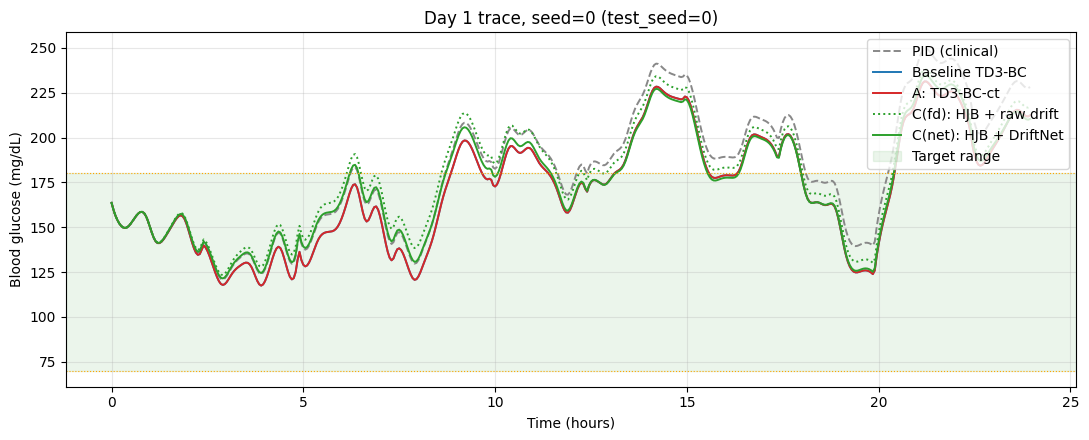

In [10]:
import matplotlib.pyplot as plt
import numpy as np

DAY_LEN = 480  # 1 day = 480 steps of 3 min
x = np.arange(DAY_LEN) * 3 / 60.0  # hours

styles = {
    "PID":      ("PID (clinical)",        {"color": "#888888", "linestyle": "--"}),
    "baseline": ("Baseline TD3-BC",       {"color": "#1f77b4"}),
    "A":        ("A: TD3-BC-ct",          {"color": "#d62728"}),
    "C_fd":     ("C(fd): HJB + raw drift",{"color": "#2ca02c", "linestyle": ":"}),
    "C_net":    ("C(net): HJB + DriftNet",{"color": "#2ca02c"}),
}

fig, ax = plt.subplots(figsize=(11, 4.5))
for key, (label, style) in styles.items():
    if key not in results or not results[key]:
        continue
    bg = np.asarray(results[key][0])[:DAY_LEN]
    ax.plot(x[:len(bg)], bg, label=label, linewidth=1.4, **style)

ax.axhspan(70, 180, alpha=0.08, color="green", label="Target range")
ax.axhline(70,  color="orange", linewidth=0.8, linestyle=":")
ax.axhline(180, color="orange", linewidth=0.8, linestyle=":")
ax.set_xlabel("Time (hours)"); ax.set_ylabel("Blood glucose (mg/dL)")
ax.set_title(f"Day 1 trace, seed={SEEDS[0]} (test_seed={TEST_SEED})")
ax.legend(loc="upper right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()